In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use("ggplot")

# Display large numbers without scientific notation
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
df = pd.read_csv("F:/youtube-content-intelligence/data/cleaned/videos_cleaned.csv")

df.head()

,channel,video_id,title,url,views,upload_date,duration_seconds,description,thumbnail,like_count,...,channel_subscribers,tags,year,month,day,duration_minutes,engagement_rate,description_length,title_length,tag_count
0,Matt Wolfe - Videos,XbHeJL45USQ,GLM-5.2 Proves Open-Source AI is Finally Good ...,https://www.youtube.com/watch?v=XbHeJL45USQ,23972,2026-07-01,1732,"Z.ai's GLM-5.2 is a 1 million token, MIT-licen...",https://i.ytimg.com/vi/XbHeJL45USQ/maxresdefau...,"1,092.00",...,"973,000.00","AI, Artificial Intelligence, FutureTools, Futu...",2026,July,Wednesday,28.87,5.24,2023,50,27
1,Matt Wolfe - Videos,zMVZvgCOr40,AI News: The New Model That's As Good As Fable,https://www.youtube.com/watch?v=zMVZvgCOr40,97768,2026-06-26,1200,Stop losing money on separate AI subscriptions...,https://i.ytimg.com/vi/zMVZvgCOr40/maxresdefau...,"2,979.00",...,"973,000.00","AI, Artificial Intelligence, FutureTools, Futu...",2026,June,Friday,20.00,3.26,2048,46,29
2,Matt Wolfe - Videos,STH929HARLo,9 Free AI Skills That Feel Like Cheat Codes,https://www.youtube.com/watch?v=STH929HARLo,78613,2026-06-24,1754,9 free skills and plug-ins that make Claude Co...,https://i.ytimg.com/vi/STH929HARLo/maxresdefau...,"3,382.00",...,"973,000.00","AI, Artificial Intelligence, FutureTools, Futu...",2026,June,Wednesday,29.23,4.48,2653,43,27
3,Matt Wolfe - Videos,Db260rUuKJg,AI News: No One Saw This Coming!,https://www.youtube.com/watch?v=Db260rUuKJg,84265,2026-06-19,2144,Here's The AI News You Probably Missed This We...,https://i.ytimg.com/vi/Db260rUuKJg/maxresdefau...,"2,879.00",...,"973,000.00","AI, Artificial Intelligence, FutureTools, Futu...",2026,June,Friday,35.73,3.84,2724,32,10
4,Matt Wolfe - Videos,_7BHqZayPOc,I Tried PewDiePie’s Odysseus AI So You Don’t H...,https://www.youtube.com/watch?v=_7BHqZayPOc,63604,2026-06-17,1907,Try Recraft V4.1 now and experience an image g...,https://i.ytimg.com/vi/_7BHqZayPOc/maxresdefau...,"1,599.00",...,"973,000.00","AI, Artificial Intelligence, FutureTools, Matt...",2026,June,Wednesday,31.78,2.82,2290,63,28


In [4]:
print("Shape:", df.shape)

df.info()

df.describe()

Shape: (335, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   channel              335 non-null    object 
 1   video_id             335 non-null    object 
 2   title                335 non-null    object 
 3   url                  335 non-null    object 
 4   views                335 non-null    int64  
 5   upload_date          335 non-null    object 
 6   duration_seconds     335 non-null    int64  
 7   description          335 non-null    object 
 8   thumbnail            335 non-null    object 
 9   like_count           335 non-null    float64
 10  comment_count        335 non-null    float64
 11  channel_subscribers  335 non-null    float64
 12  tags                 180 non-null    object 
 13  year                 335 non-null    int64  
 14  month                335 non-null    object 
 15  day                  33

,views,duration_seconds,like_count,comment_count,channel_subscribers,year,duration_minutes,engagement_rate,description_length,title_length,tag_count
count,335.00,335.00,335.00,335.00,335.00,335.00,335.00,335.00,335.00,335.00,335.00
mean,"201,004.21","1,189.06","7,223.27",490.13,"1,551,532.03","2,025.64",19.82,3.83,"1,613.00",51.12,8.45
std,"387,165.95",756.17,"13,545.59",865.43,"1,601,662.19",1.77,12.60,1.27,"1,083.12",17.53,12.26
min,34.00,94.00,0.00,0.00,46.00,"2,011.00",1.57,0.00,28.00,15.00,0.00
25%,"11,235.50",600.00,441.00,49.50,"395,000.00","2,026.00",10.00,3.23,634.00,38.00,0.00
50%,"61,259.00","1,100.00","2,288.00",226.00,"973,000.00","2,026.00",18.33,3.74,"1,362.00",50.00,2.00
75%,"161,796.00","1,597.50","6,458.50",494.50,"1,820,000.00","2,026.00",26.62,4.50,"2,452.50",61.50,18.00
max,"3,227,473.00","6,447.00","99,685.00","9,500.00","5,310,000.00","2,026.00",107.45,8.33,"4,845.00",98.00,47.00


# Observation

Dataset contains ___ videos

Dataset contains ___ columns

Numerical variables include views, likes, comments, duration, subscribers.

No missing values remain after preprocessing.

Section 1: Channel Performance

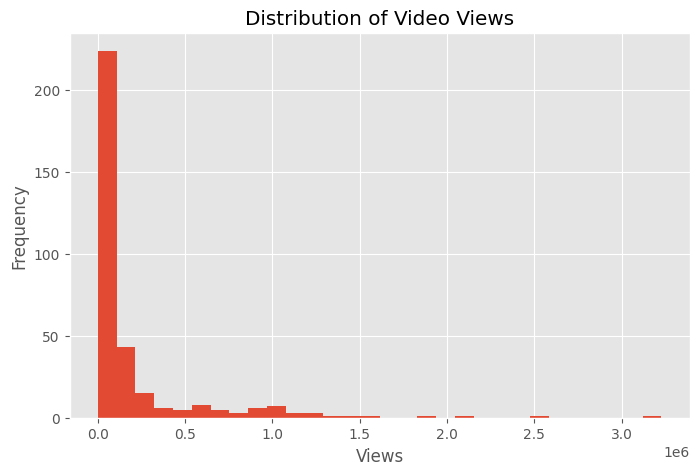

In [5]:
plt.figure(figsize=(8,5))

plt.hist(df["views"], bins=30)

plt.title("Distribution of Video Views")

plt.xlabel("Views")

plt.ylabel("Frequency")

plt.show()

Distribution of Views

Observation

The distribution is highly right-skewed.

Most videos receive relatively low to moderate view counts.

A small number of videos have exceptionally high views (over 1–3 million).

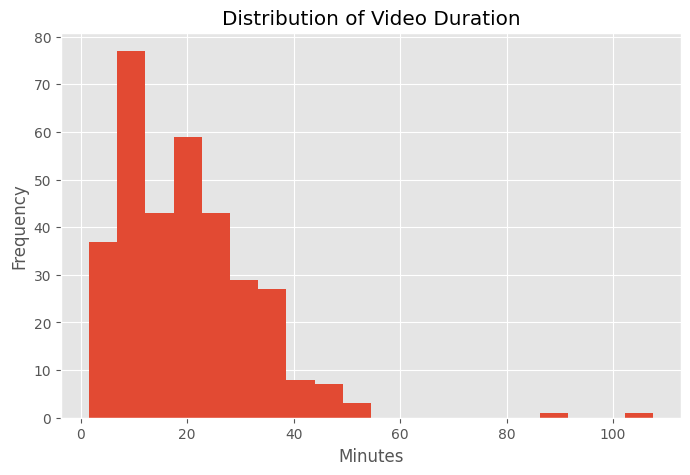

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["duration_minutes"], bins=20)

plt.title("Distribution of Video Duration")

plt.xlabel("Minutes")

plt.ylabel("Frequency")

plt.show()

Distribution of Duration

Observation

Most videos fall between 10 and 30 minutes.

Very few videos exceed 40 minutes.

A small number of videos are extremely long (around 90–100 minutes), making them clear outliers.

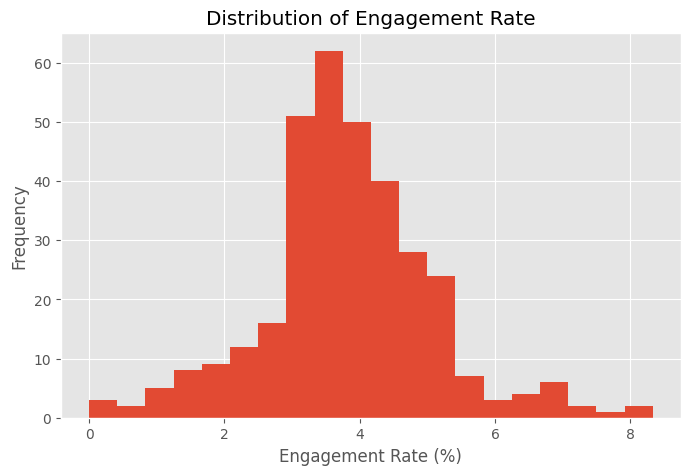

In [7]:
plt.figure(figsize=(8,5))

plt.hist(df["engagement_rate"], bins=20)

plt.title("Distribution of Engagement Rate")

plt.xlabel("Engagement Rate (%)")

plt.ylabel("Frequency")

plt.show()

Distribution of Engagement Rate

Observation

Most videos have an engagement rate between 3% and 5%.

Very few videos fall below 2% or exceed 7%.

The distribution is fairly concentrated around the middle.

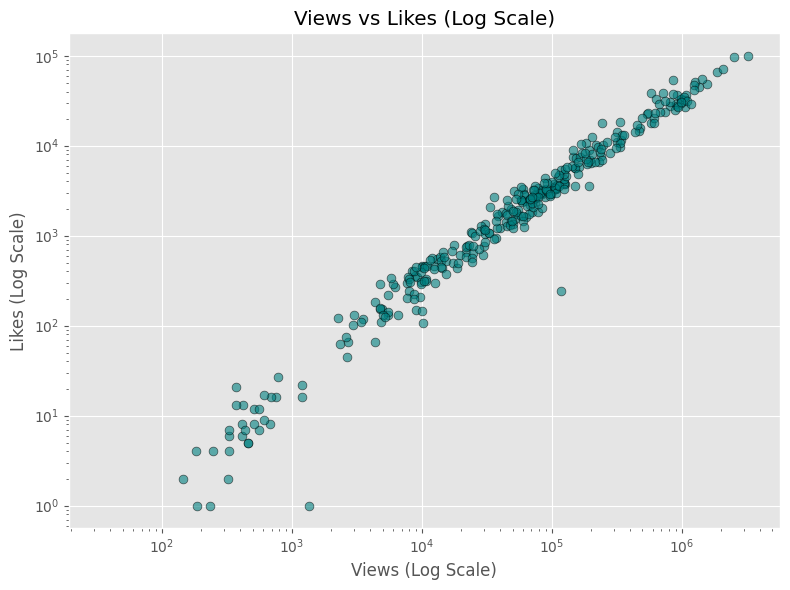

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["views"],
    df["like_count"],
    color="teal",
    alpha=0.6,
    edgecolors="black",
    s=40
)

plt.xscale("log")
plt.yscale("log")

plt.title("Views vs Likes (Log Scale)")
plt.xlabel("Views (Log Scale)")
plt.ylabel("Likes (Log Scale)")

plt.tight_layout()
plt.show()

Observation

The scatter plot shows an upward trend where videos with higher views generally receive more likes

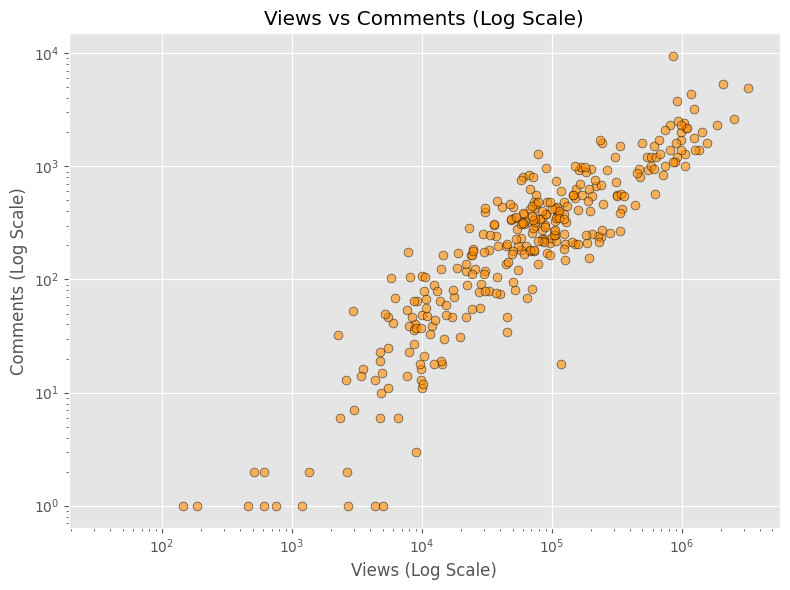

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["views"],
    df["comment_count"],
    color="darkorange",
    alpha=0.6,
    edgecolors="black",
    s=40
)

plt.xscale("log")
plt.yscale("log")

plt.title("Views vs Comments (Log Scale)")

plt.xlabel("Views (Log Scale)")

plt.ylabel("Comments (Log Scale)")

plt.tight_layout()

plt.show()

Observation

The scatter plot shows a clear positive relationship between views and comments.

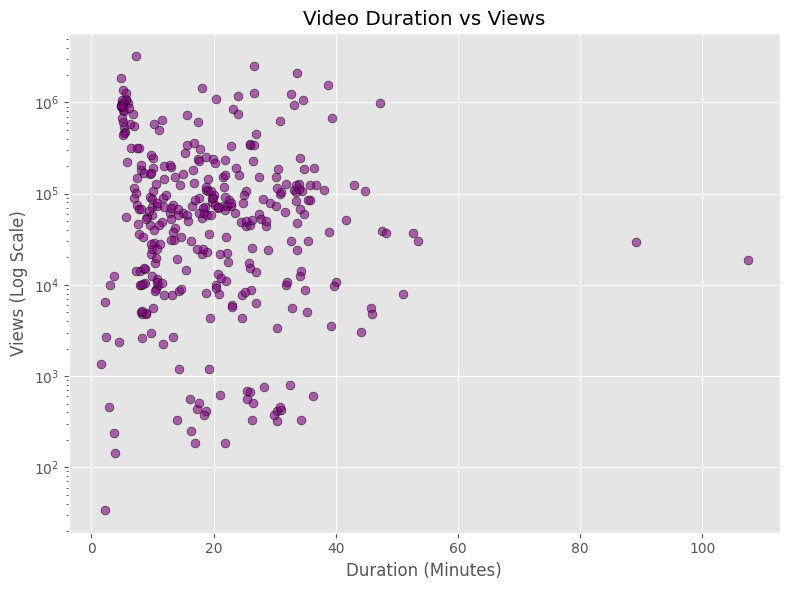

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["duration_minutes"],
    df["views"],
    color="purple",
    alpha=0.6,
    edgecolors="black",
    s=40
)

# Only use log scale for Views
plt.yscale("log")

plt.title("Video Duration vs Views")

plt.xlabel("Duration (Minutes)")

plt.ylabel("Views (Log Scale)")

plt.tight_layout()

plt.show()

Observation

The scatter plot does not show a clear relationship between video duration and view count. Videos of different lengths receive both low and high numbers of views.

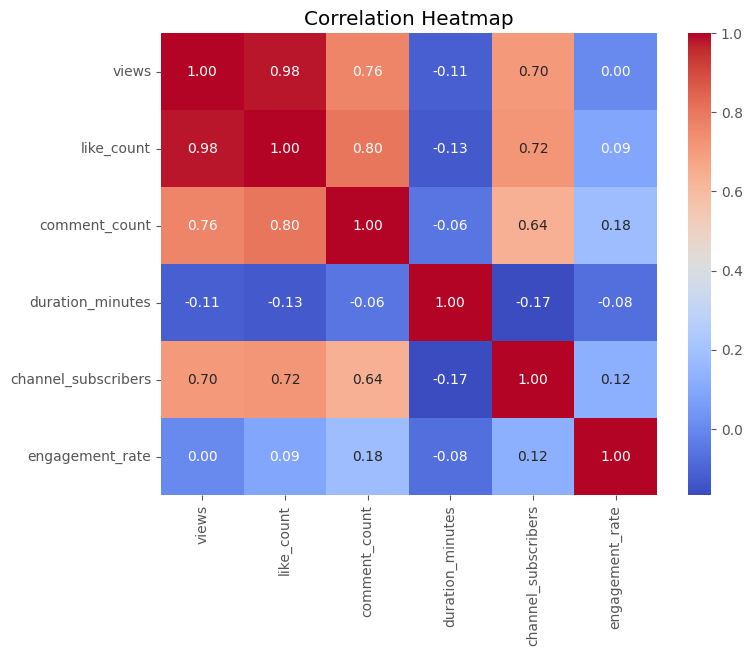

In [11]:
import seaborn as sns

numeric_cols = [
    "views",
    "like_count",
    "comment_count",
    "duration_minutes",
    "channel_subscribers",
    "engagement_rate"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Observation

The correlation heatmap reveals several important relationships:

Views and Likes have a very strong positive correlation (0.98).

Likes and Comments also show a strong positive correlation (0.80).

Views and Comments have a strong positive correlation (0.76).

Channel Subscribers have a moderate positive correlation with Views (0.70), Likes (0.72), and Comments (0.64).

Video Duration has a very weak negative correlation with all engagement metrics.

Engagement Rate shows little to no correlation with the other variables.

In [13]:
top_views = (
    df.sort_values("views", ascending=False)
      .head(10)
)

top_views[["title", "channel", "views"]]

,title,channel,views
202,Tragic mistake... Anthropic leaks Claude’s sou...,Fireship - Videos,3227473
331,"You NEED to Use n8n RIGHT NOW!! (Free, Local, ...",NetworkChuck - Videos,2537598
325,You've Been Using AI the Hard Way (Use This In...,NetworkChuck - Videos,2082898
207,Google just changed the future of UI/UX design...,Fireship - Videos,1870439
328,you need to learn MCP RIGHT NOW!! (Model Conte...,NetworkChuck - Videos,1572752
329,THIS Is Where the Internet Lives,NetworkChuck - Videos,1432603
199,Google just casually disrupted the open-source...,Fireship - Videos,1356813
201,He just crawled through hell to fix the browser…,Fireship - Videos,1267372
330,Hacking AI is TOO EASY (this should be illegal),NetworkChuck - Videos,1254057
308,you need to use Hermes RIGHT NOW!! (goodbye Op...,NetworkChuck - Videos,1248104


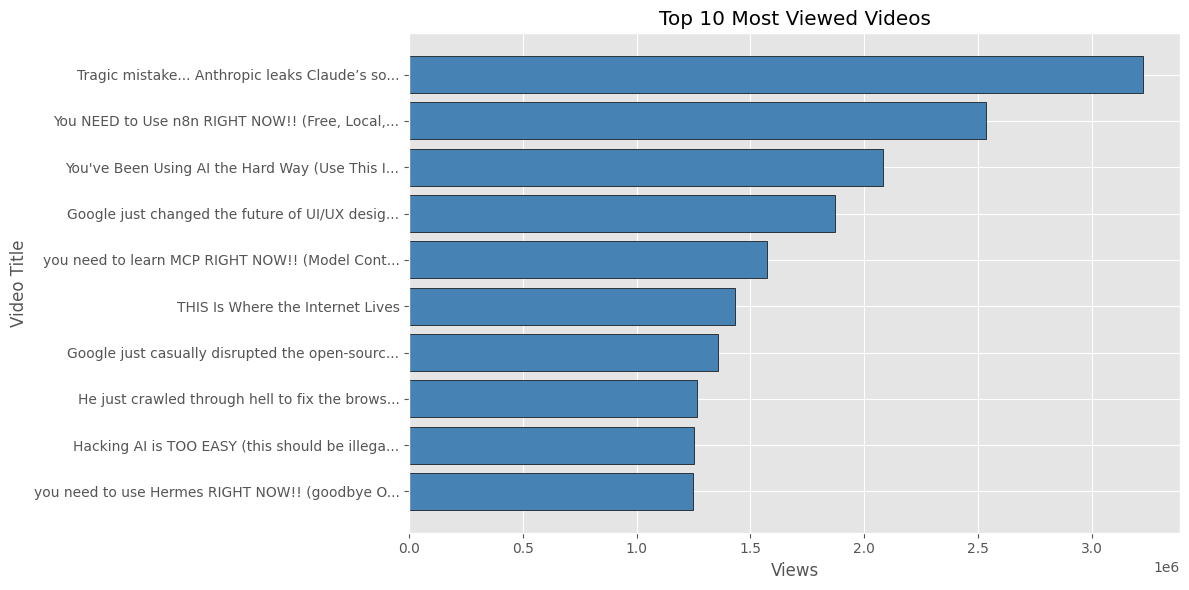

In [15]:
top_views = df.sort_values("views", ascending=False).head(10).copy()

top_views["short_title"] = top_views["title"].apply(
    lambda x: x[:45] + "..." if len(x) > 45 else x
)

plt.figure(figsize=(12,6))

plt.barh(
    top_views["short_title"],
    top_views["views"],
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Most Viewed Videos")
plt.xlabel("Views")
plt.ylabel("Video Title")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Observation

The chart shows that a small number of videos achieved exceptionally high view counts compared to the rest of the dataset. Many of the top-performing videos focus on trending AI news, popular AI tools, and practical tutorials, indicating strong audience interest in timely and actionable content.

In [16]:
top_engagement = (
    df.sort_values("engagement_rate", ascending=False)
      .head(10)
      .copy()
)

top_engagement["short_title"] = top_engagement["title"].apply(
    lambda x: x[:45] + "..." if len(x) > 45 else x
)

top_engagement[["title", "channel", "engagement_rate"]]

,title,channel,engagement_rate
113,The Algorithm That Made Me Cry,Two Minute Papers - Videos,8.33
112,DeepMind’s New AI Just Changed Science Forever,Two Minute Papers - Videos,7.93
65,Seedance AI Shortfilm | Breakdown using Pollo ...,MattVidPro - Videos,7.65
312,I almost quit YouTube....,NetworkChuck - Videos,7.33
57,"An ‘AI Bubble’? What Altman Actually said, the...",AI Explained - Videos,7.27
183,I read every major CS paper of the last 100 ye...,Fireship - Videos,6.88
305,you only have 6 days....,NetworkChuck - Videos,6.86
111,Google’s New AI Just Broke My Brain,Two Minute Papers - Videos,6.82
18,How Much Does a 900k YouTube Channel Make? (An...,Matt Wolfe - Videos,6.79
245,Ubtechs New U1 UWORLD Robots Shocked The Robot...,TheAIGRID - Videos,6.79


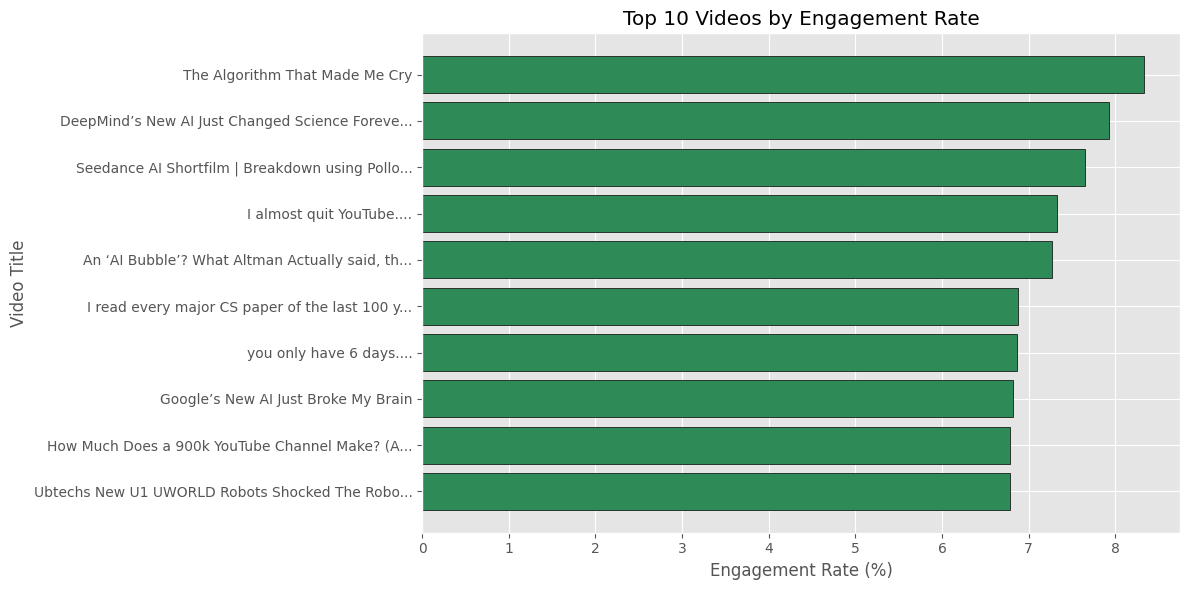

In [17]:
plt.figure(figsize=(12,6))

plt.barh(
    top_engagement["short_title"],
    top_engagement["engagement_rate"],
    color="seagreen",
    edgecolor="black"
)

plt.title("Top 10 Videos by Engagement Rate")

plt.xlabel("Engagement Rate (%)")
plt.ylabel("Video Title")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()